In [1]:
import random
import json
import os
import re
import warnings
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

train = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/train.csv')
test = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/test.csv')
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
train.head()

Train shape: (14397, 4), Test shape: (3603, 3)


,id,title,content,label
0,tr00000,Tak Lagi Jadi Jubir Yurianto Tak Umumkan Updat...,Ada perubahan besar besaran dalam pemaparan da...,0
1,tr00001,Aturan Swab PCR Bagi Penumpang Pesawat ke Kalb...,Aturan Swab PCR Bagi Penumpang Pesawat ke Kalb...,1
2,tr00002,Tim Riset Vaksin Sinovac Siapkan Laporan Perda...,Tim riset dari Fakultas Kedokteran Universitas...,1
3,tr00003,Kasus Corona Meksiko Kini Lebih dari 500 Ribu ...,Meksiko melaporkan kasus infeksi virus corona ...,1
4,tr00004,Menag Di Negara Pancasila Tak Ada Diktator Ma...,Menteri Agama Menag Yaqut Cholil Qoumas menj...,1


In [3]:
label_names = {0: 'Tidak Sesuai', 1: 'Sesuai'}

def dataset_inspection(df, name="dataset"):
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nDtypes:\n{df.dtypes.to_string()}")
    print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
    for col in df.select_dtypes(include='object').columns:
        empty_count = (df[col].astype(str).str.strip() == '').sum()
        print(f"Empty strings in '{col}': {empty_count}")
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    print()

dataset_inspection(train, "Train")
dataset_inspection(test, "Test")

# Auto-discover text columns & label
text_cols = [c for c in train.columns if train[c].dtype == 'object' and c != 'id']
label_col = [c for c in train.columns if c not in text_cols and c != 'id'][0]

print(f"Auto-discovered text columns: {text_cols}")
print(f"Auto-discovered label column: {label_col}")

# Map to internal names (verify manually!)
headline_col = text_cols[0]
article_col = text_cols[1]
print(f"Mapped: headline='{headline_col}', article='{article_col}'")
print(f"NOTE: Verify mapping is correct! If swapped, change manually.")

# Labels
print(f"\nUnique labels: {train[label_col].unique()}")
print(f"\nLabel counts:")
print(train[label_col].value_counts().to_string())
print(f"\nLabel proportions:")
print(train[label_col].value_counts(normalize=True).to_string())

  Train
Shape: (14397, 4)

Columns: ['id', 'title', 'content', 'label']

Dtypes:
id         object
title      object
content    object
label       int64

Missing values:
id         0
title      0
content    0
label      0
Empty strings in 'id': 0
Empty strings in 'title': 0
Empty strings in 'content': 0

Duplicate rows: 0

  Test
Shape: (3603, 3)

Columns: ['id', 'title', 'content']

Dtypes:
id         object
title      object
content    object

Missing values:
id         0
title      0
content    0
Empty strings in 'id': 0
Empty strings in 'title': 0
Empty strings in 'content': 0

Duplicate rows: 0

Auto-discovered text columns: ['title', 'content']
Auto-discovered label column: label
Mapped: headline='title', article='content'
NOTE: Verify mapping is correct! If swapped, change manually.

Unique labels: [0 1]

Label counts:
label
1    12960
0     1437

Label proportions:
label
1    0.900188
0    0.099812


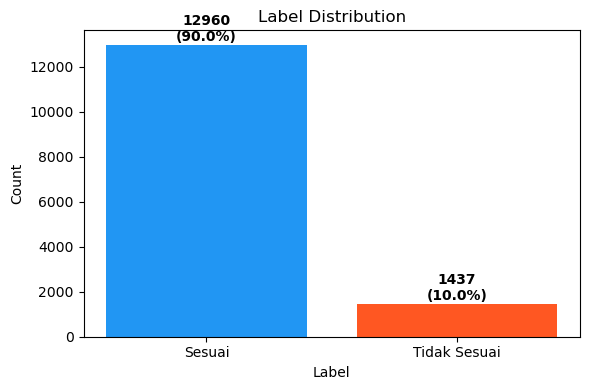


Imbalance ratio: 9.02:1
Majority baseline accuracy: 90.0%
NOTE: Macro F1 is sensitive to imbalance — need balanced class weights or threshold tuning.


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
label_counts = train[label_col].value_counts()
display_names = [label_names.get(int(l), str(l)) for l in label_counts.index]

bars = ax.bar(display_names, label_counts.values, color=['#2196F3', '#FF5722'])
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{count}\n({count/len(train)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Label Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Majority baseline accuracy: {label_counts.max()/len(train)*100:.1f}%")
print(f"NOTE: Macro F1 is sensitive to imbalance — need balanced class weights or threshold tuning.")

=== Text Length Statistics ===

headline_char_len:
  mean=63.8, median=62.0, min=17, max=150, std=11.0

headline_word_len:
  mean=10.1, median=10.0, min=3, max=23, std=2.0

article_char_len:
  mean=2126.8, median=1893.0, min=16, max=31584, std=1200.2

article_word_len:
  mean=309.9, median=276.0, min=3, max=4238, std=169.6


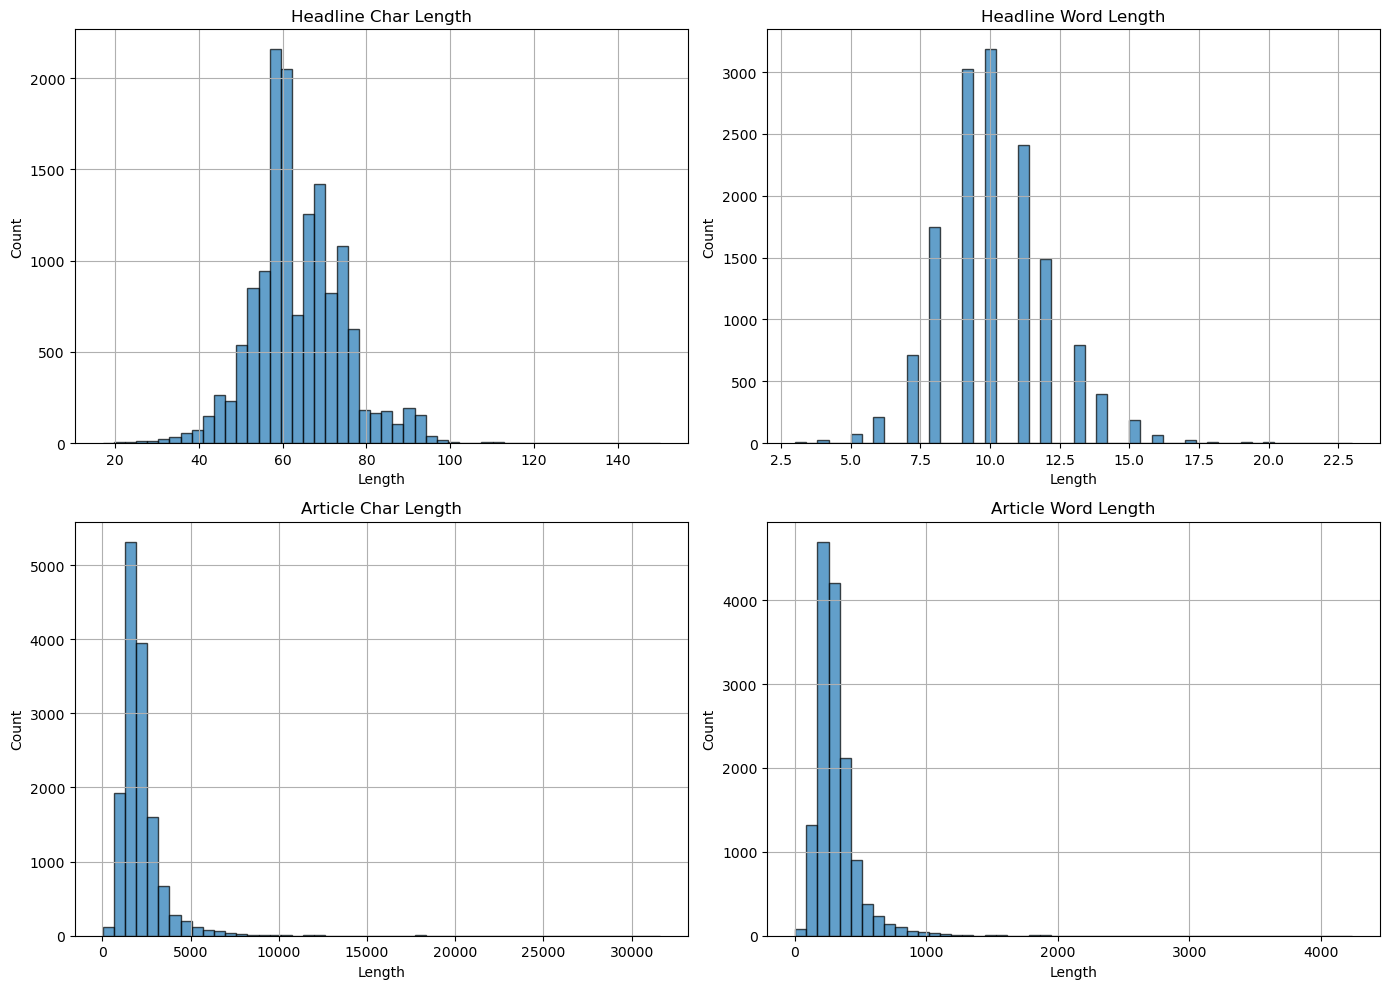

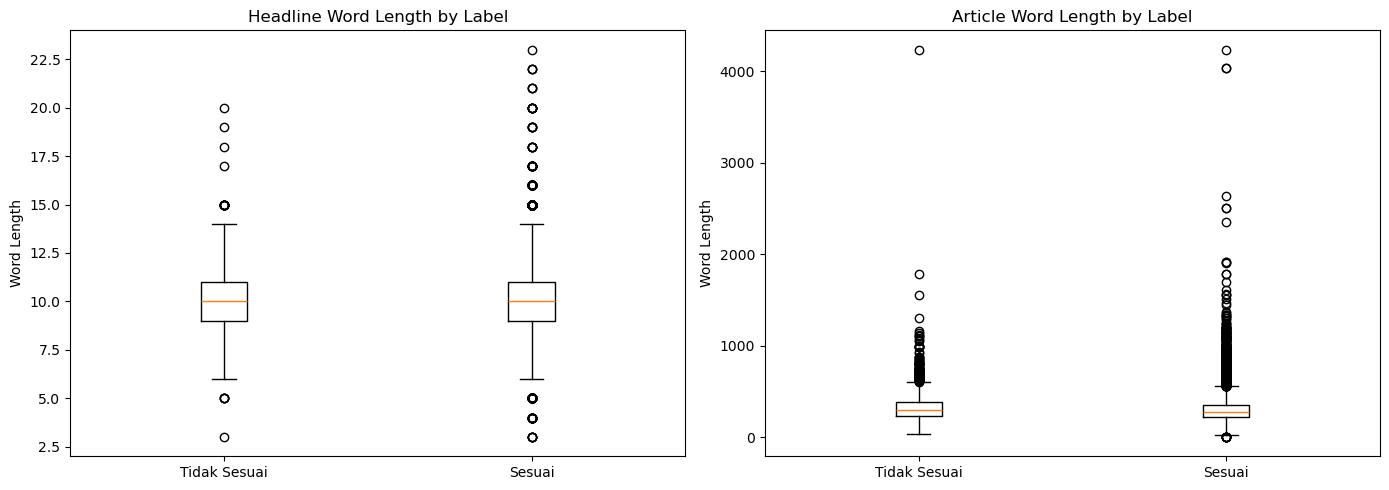


=== Outlier Analysis (IQR Method) ===
headline outliers: 415 (2.88%)
  range: [6.0, 14.0], actual min=3, max=23
  NOTE: Outliers NOT removed — only analyzed. Review before deciding.
article outliers: 796 (5.53%)
  range: [11.0, 563.0], actual min=3, max=4238
  NOTE: Outliers NOT removed — only analyzed. Review before deciding.


In [5]:
def compute_text_lengths(df, col, prefix):
    df = df.copy()
    df[f'{prefix}_char_len'] = df[col].astype(str).str.len()
    df[f'{prefix}_word_len'] = df[col].astype(str).apply(lambda x: len(x.split()))
    return df

train = compute_text_lengths(train, headline_col, 'headline')
train = compute_text_lengths(train, article_col, 'article')

# Statistics
print("=== Text Length Statistics ===")
for metric in ['headline_char_len', 'headline_word_len', 'article_char_len', 'article_word_len']:
    s = train[metric]
    print(f"\n{metric}:")
    print(f"  mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}, std={s.std():.1f}")

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, title in zip(axes.flat,
    ['headline_char_len', 'headline_word_len', 'article_char_len', 'article_word_len'],
    ['Headline Char Length', 'Headline Word Length', 'Article Char Length', 'Article Word Length']):
    train[col].hist(bins=50, ax=ax, alpha=0.7, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Length')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prefix, title in zip(axes, ['headline', 'article'], ['Headline', 'Article']):
    data_to_plot = [train[train[label_col] == lbl][f'{prefix}_word_len'] for lbl in sorted(train[label_col].unique())]
    ax.boxplot(data_to_plot, labels=[label_names.get(int(l), str(l)) for l in sorted(train[label_col].unique())])
    ax.set_title(f'{title} Word Length by Label')
    ax.set_ylabel('Word Length')
plt.tight_layout()
plt.show()

# Outlier analysis (IQR method)
print("\n=== Outlier Analysis (IQR Method) ===")
for prefix in ['headline', 'article']:
    col = f'{prefix}_word_len'
    q1, q3 = train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    print(f"{prefix} outliers: {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)")
    print(f"  range: [{lower:.1f}, {upper:.1f}], actual min={train[col].min()}, max={train[col].max()}")
    print(f"  NOTE: Outliers NOT removed — only analyzed. Review before deciding.")

In [6]:
def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    return words_freq

# Global top unigrams & bigrams
for n, label_n in [(1, 'unigram'), (2, 'bigram')]:
    print(f"\n{'='*50}")
    print(f"  Top {label_n.upper()} (Global)")
    print(f"{'='*50}")
    for text_col, text_name in [(headline_col, 'Headline'), (article_col, 'Article')]:
        top = get_top_ngrams(train[text_col].astype(str), n=n, top_k=15)
        print(f"\n  {text_name}:")
        for word, freq in top:
            print(f"    {word}: {freq}")

# Per label
for lbl in sorted(train[label_col].unique()):
    subset = train[train[label_col] == lbl]
    lbl_name = label_names.get(int(lbl), str(lbl))
    print(f"\n{'='*50}")
    print(f"  Label: {lbl_name} ({lbl})")
    print(f"{'='*50}")
    for n, label_n in [(1, 'unigram'), (2, 'bigram')]:
        for text_col, text_name in [(headline_col, 'Headline'), (article_col, 'Article')]:
            top = get_top_ngrams(subset[text_col].astype(str), n=n, top_k=10)
            print(f"\n  Top {label_n} ({text_name}):")
            for word, freq in top:
                print(f"    {word}: {freq}")


  Top UNIGRAM (Global)

  Headline:
    di: 4287
    corona: 4255
    covid: 4046
    19: 3251
    positif: 1771
    kasus: 1747
    vaksin: 1101
    ini: 1001
    dan: 995
    tak: 880
    baru: 877
    kumparan: 874
    com: 874
    yang: 712
    dki: 691

  Article:
    yang: 97657
    di: 91852
    dan: 78158
    19: 49526
    covid: 49153
    ini: 47704
    dari: 43823
    untuk: 39567
    itu: 37190
    dengan: 35555
    kasus: 32514
    dalam: 30397
    pada: 26640
    ada: 25698
    tidak: 25052

  Top BIGRAM (Global)

  Headline:
    covid 19: 3175
    kumparan com: 874
    positif covid: 780
    positif corona: 667
    corona di: 578
    19 di: 491
    kasus corona: 411
    vaksin corona: 373
    vaksin covid: 306
    kasus covid: 304
    pasien covid: 256
    update corona: 251
    virus corona: 247
    habib rizieq: 245
    zona merah: 243

  Article:
    covid 19: 46871
    virus corona: 12222
    protokol kesehatan: 7903
    saat ini: 7203
    19 di: 6653
    hari ini: 5

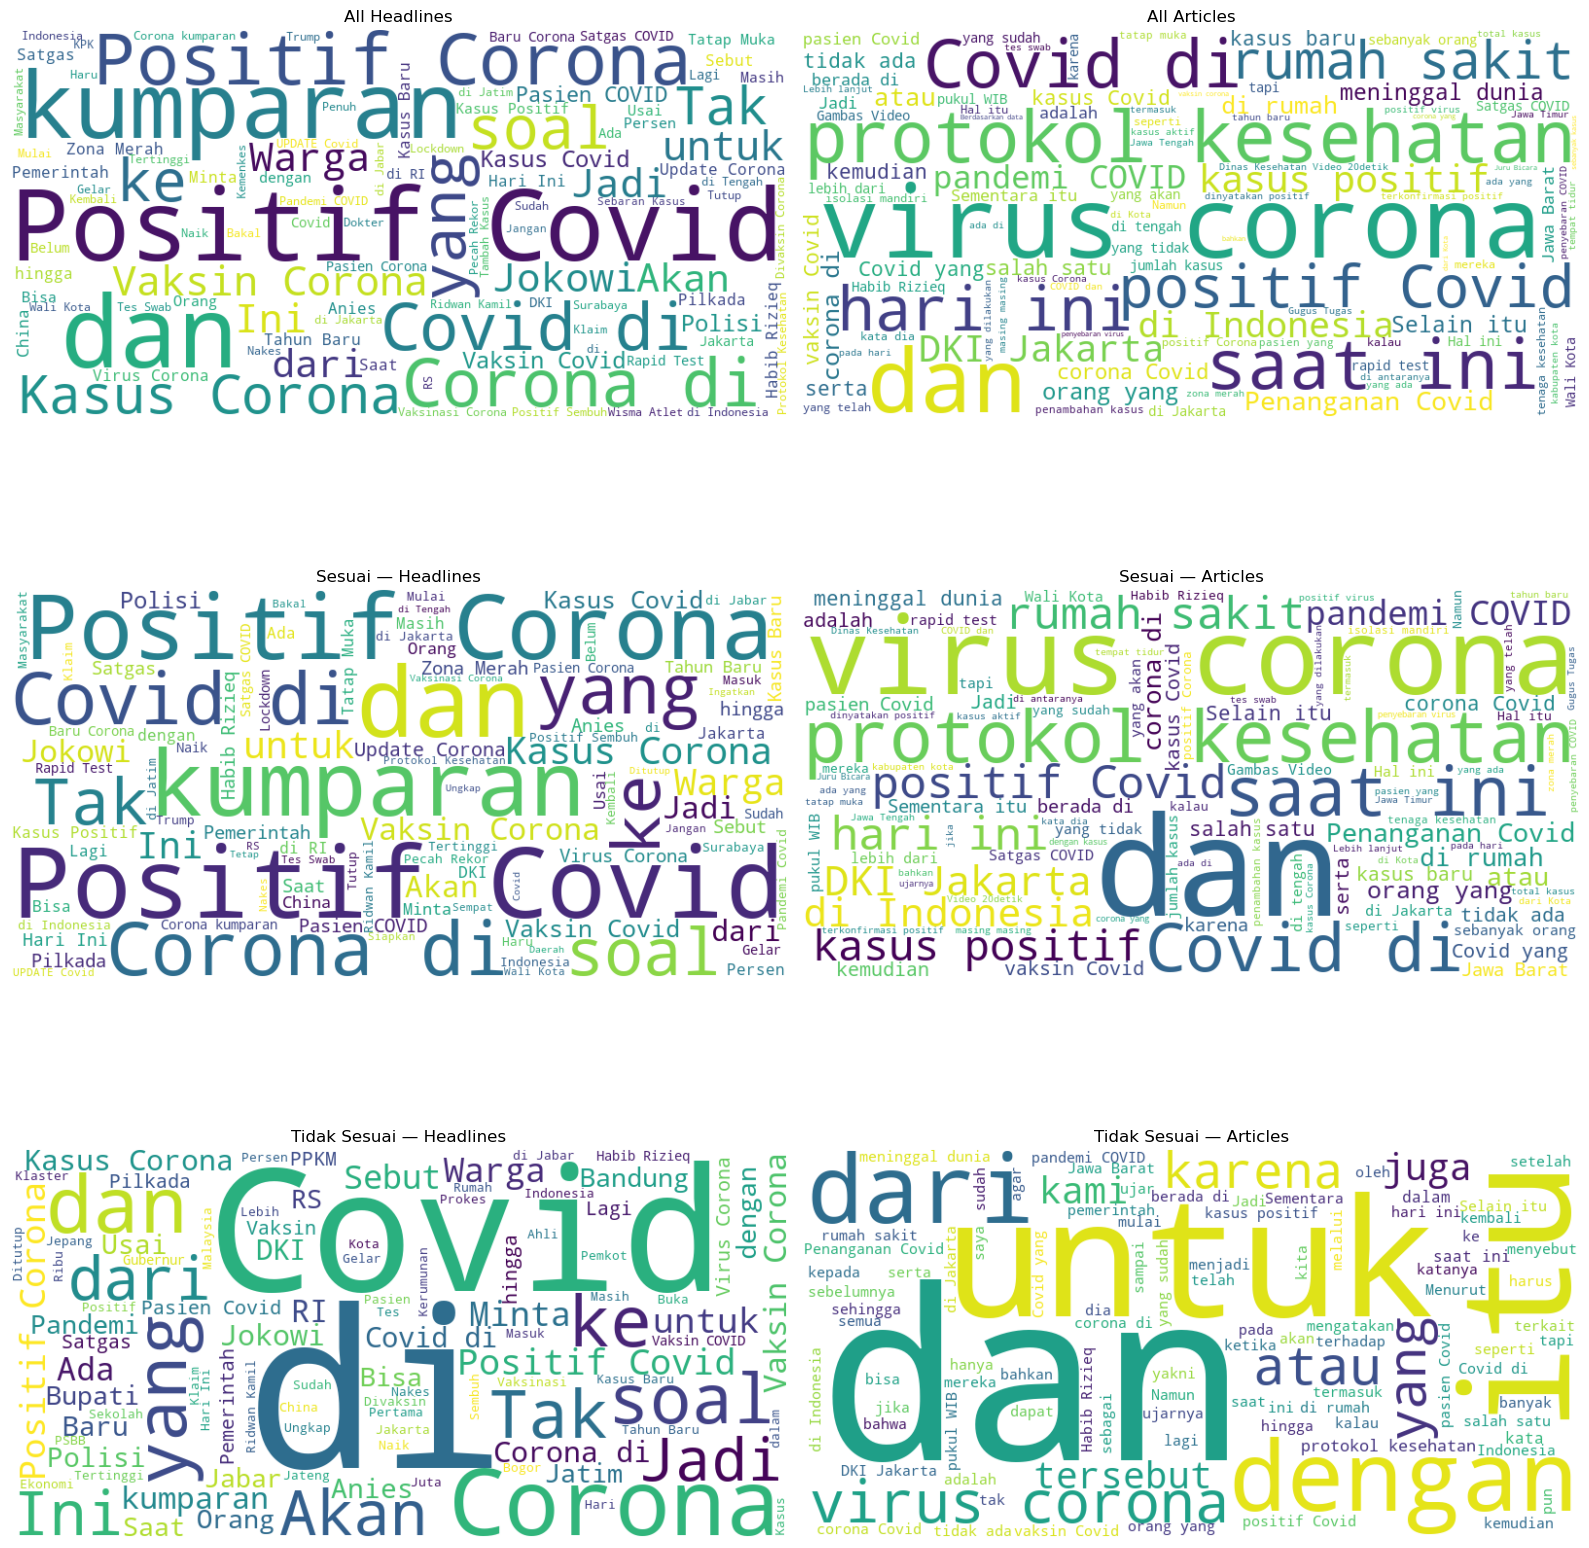

In [7]:
def create_wordcloud(corpus, title, ax):
    text = ' '.join(corpus.astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
corpora = [
    (train[headline_col], 'All Headlines'),
    (train[article_col], 'All Articles'),
    (train[train[label_col]==1][headline_col], 'Sesuai — Headlines'),
    (train[train[label_col]==1][article_col], 'Sesuai — Articles'),
    (train[train[label_col]==0][headline_col], 'Tidak Sesuai — Headlines'),
    (train[train[label_col]==0][article_col], 'Tidak Sesuai — Articles'),
]
for ax, (corpus, title) in zip(axes.flat, corpora):
    create_wordcloud(corpus, title, ax)
plt.tight_layout()
plt.show()

In [8]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time

N_WORKERS = min(4, os.cpu_count() or 2)
print(f"Using {N_WORKERS} workers for parallel processing\n")

def log_step(step_name, df, col, affected_mask=None):
    if affected_mask is not None:
        n_affected = affected_mask.sum()
        print(f"  [{step_name}] {col}: {n_affected} rows affected ({n_affected/len(df)*100:.2f}%)")
    else:
        print(f"  [{step_name}] {col}: applied to all rows")

def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def remove_url(text):
    return re.sub(r'https?://\S+|www\.\S+', '', str(text))

def remove_html(text):
    return re.sub(r'<[^>]+>', '', str(text))

def remove_noise(text):
    text = re.sub(r'\S+@\S+', '', str(text))
    text = re.sub(r'[^\w\s.,;:!?%$()\-/+]', '', text)
    return text

def lowercase(text):
    return str(text).lower()

def apply_step_parallel(df, col, step_func, step_name):
    """Apply a text cleaning function in parallel using ThreadPoolExecutor."""
    texts = df[col].astype(str).tolist()
    results = [None] * len(texts)
    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {executor.submit(step_func, txt): i for i, txt in enumerate(texts)}
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"  {step_name} ({col})", leave=False):
            idx = futures[future]
            results[idx] = future.result()
    return results

def apply_step_series(df, col, step_func, step_name):
    """Fallback: apply step as pandas Series op (for steps that need mask)."""
    return df[col].apply(step_func)

# ============================================================
# VARIANT A: Light Cleaning
# ============================================================
print("=== Variant A: Light Cleaning ===")
t0 = time.time()
for col in [headline_col, article_col]:
    print(f"\n  Processing: {col}")

    # normalize_whitespace
    mask = train[col].astype(str).apply(lambda x: bool(re.search(r'\s{2,}', str(x))))
    train[f'{col}_clean_a'] = pd.Series(apply_step_parallel(train, col, normalize_whitespace, 'normalize_whitespace'))
    log_step('normalize_whitespace', train, col, mask)

    # remove_url
    mask = train[f'{col}_clean_a'].astype(str).apply(lambda x: bool(re.search(r'https?://|www\.', str(x))))
    train[f'{col}_clean_a'] = pd.Series(apply_step_parallel(train, f'{col}_clean_a', remove_url, 'remove_url'))
    log_step('remove_url', train, col, mask)

    # remove_html
    mask = train[f'{col}_clean_a'].astype(str).apply(lambda x: bool(re.search(r'<[^>]+>', str(x))))
    train[f'{col}_clean_a'] = pd.Series(apply_step_parallel(train, f'{col}_clean_a', remove_html, 'remove_html'))
    log_step('remove_html', train, col, mask)

    # remove_noise
    mask = train[f'{col}_clean_a'].astype(str).apply(lambda x: bool(re.search(r'\S+@|<|>', str(x))))
    train[f'{col}_clean_a'] = pd.Series(apply_step_parallel(train, f'{col}_clean_a', remove_noise, 'remove_noise'))
    log_step('remove_noise', train, col, mask)

print(f"\nVariant A completed in {time.time()-t0:.1f}s")

# ============================================================
# VARIANT B: Normalized (light + lowercase + stopword)
# ============================================================
print("\n=== Variant B: Normalized ===")
t0 = time.time()
for col in [headline_col, article_col]:
    print(f"\n  Processing: {col}")

    # lowercase
    train[f'{col}_clean_b'] = pd.Series(apply_step_parallel(train, f'{col}_clean_a', lowercase, 'lowercase'))
    log_step('lowercase', train, col, pd.Series([True]*len(train)))

    # stopword removal (Sastrawi)
    try:
        stop_factory = StopWordRemoverFactory()
        stop_words = set(stop_factory.get_stop_words())
        def remove_stopwords(text):
            words = str(text).split()
            return ' '.join([w for w in words if w not in stop_words])

        original_lens = train[f'{col}_clean_b'].apply(lambda x: len(str(x).split()))
        train[f'{col}_clean_b'] = pd.Series(apply_step_parallel(train, f'{col}_clean_b', remove_stopwords, 'stopword_removal'))
        new_lens = train[f'{col}_clean_b'].apply(lambda x: len(str(x).split()))
        mask = original_lens != new_lens
        log_step('stopword_removal', train, col, mask)
    except Exception as e:
        print(f"  [stopword_removal] Sastrawi not available: {e}")

print(f"\nVariant B completed in {time.time()-t0:.1f}s")

# Verify raw text preserved
print("\n=== Verification: Raw text preserved ===")
print(f"Raw headline sample:     {train[headline_col].iloc[0][:100]}...")
print(f"Clean A (light):         {train[f'{headline_col}_clean_a'].iloc[0][:100]}...")
print(f"Clean B (normalized):    {train[f'{headline_col}_clean_b'].iloc[0][:100]}...")

Using 4 workers for parallel processing

=== Variant A: Light Cleaning ===

  Processing: title


  [normalize_whitespace] title: 5300 rows affected (36.81%)


  [remove_url] title: 0 rows affected (0.00%)


  [remove_html] title: 0 rows affected (0.00%)


  [remove_noise] title: 0 rows affected (0.00%)

  Processing: content


...

  [remove_noise] content: 0 rows affected (0.00%)

Variant A completed in 9.1s

=== Variant B: Normalized ===

  Processing: title


  [lowercase] title: 14397 rows affected (100.00%)


  [stopword_removal] title: 9586 rows affected (66.58%)

  Processing: content


  [lowercase] content: 14397 rows affected (100.00%)


  [stopword_removal] content: 14388 rows affected (99.94%)

Variant B completed in 3.4s

=== Verification: Raw text preserved ===
Raw headline sample:     Tak Lagi Jadi Jubir Yurianto Tak Umumkan Update Harian Covid...
Clean A (light):         Tak Lagi Jadi Jubir Yurianto Tak Umumkan Update Harian Covid...
Clean B (normalized):    tak jadi jubir yurianto tak umumkan update harian covid...


In [9]:
interim_dir = '../data/interim'
os.makedirs(interim_dir, exist_ok=True)

processing_log = {
    "created_at": datetime.now().isoformat(),
    "source": "../data/raw/penyisihan-dac-ifest-2026/train.csv",
    "total_rows": int(len(train)),
    "columns_processed": [headline_col, article_col],
    "variants": {}
}

# Save each variant as separate CSV
for variant_suffix, variant_name, steps in [
    ('clean_a', 'A_light', ['normalize_whitespace', 'remove_url', 'remove_html', 'remove_noise']),
    ('clean_b', 'B_normalized', ['normalize_whitespace', 'remove_url', 'remove_html', 'remove_noise', 'lowercase', 'stopword_removal']),
]:
    h_col = f'{headline_col}_{variant_suffix}'
    a_col = f'{article_col}_{variant_suffix}'

    if h_col not in train.columns or a_col not in train.columns:
        print(f"  Skipping {variant_name}: columns not found")
        continue

    # Build save dataframe
    save_df = train[['id', label_col, headline_col, article_col, h_col, a_col]].copy()
    save_df.rename(columns={h_col: 'headline_processed', a_col: 'article_processed'}, inplace=True)

    # Save
    save_path = os.path.join(interim_dir, f'train_{variant_suffix}.csv')
    save_df.to_csv(save_path, index=False)

    # Compute stats
    h_len_before = train[headline_col].apply(lambda x: len(str(x).split()))
    h_len_after = save_df['headline_processed'].apply(lambda x: len(str(x).split()))
    a_len_before = train[article_col].apply(lambda x: len(str(x).split()))
    a_len_after = save_df['article_processed'].apply(lambda x: len(str(x).split()))

    processing_log['variants'][variant_name] = {
        "file": save_path,
        "steps": steps,
        "headline_len_reduction_pct": round((1 - h_len_after.mean() / h_len_before.mean()) * 100, 2),
        "article_len_reduction_pct": round((1 - a_len_after.mean() / a_len_before.mean()) * 100, 2),
        "rows": int(len(save_df)),
    }
    print(f"  Saved {save_path} ({len(save_df)} rows, headline reduction: {processing_log['variants'][variant_name]['headline_len_reduction_pct']}%)")

# Also save raw as reference
raw_save = train[['id', label_col, headline_col, article_col]].copy()
raw_path = os.path.join(interim_dir, 'train_raw.csv')
raw_save.to_csv(raw_path, index=False)
processing_log['variants']['raw'] = {"file": raw_path, "steps": [], "rows": int(len(raw_save))}
print(f"  Saved {raw_path} ({len(raw_save)} rows)")

# Save metadata
metadata_path = os.path.join(interim_dir, 'processing_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(processing_log, f, indent=2, ensure_ascii=False)
print(f"\nMetadata saved to: {metadata_path}")
print(json.dumps(processing_log, indent=2, ensure_ascii=False))

  Saved ../data/interim\train_clean_a.csv (14397 rows, headline reduction: 0.02%)
  Saved ../data/interim\train_clean_b.csv (14397 rows, headline reduction: 9.97%)
  Saved ../data/interim\train_raw.csv (14397 rows)

Metadata saved to: ../data/interim\processing_metadata.json
{
  "created_at": "2026-09-04T17:36:15.507225",
  "source": "../data/raw/penyisihan-dac-ifest-2026/train.csv",
  "total_rows": 14397,
  "columns_processed": [
    "title",
    "content"
  ],
  "variants": {
    "A_light": {
      "file": "../data/interim\\train_clean_a.csv",
      "steps": [
        "normalize_whitespace",
        "remove_url",
        "remove_html",
        "remove_noise"
      ],
      "headline_len_reduction_pct": 0.02,
      "article_len_reduction_pct": 0.02,
      "rows": 14397
    },
    "B_normalized": {
      "file": "../data/interim\\train_clean_b.csv",
      "steps": [
        "normalize_whitespace",
        "remove_url",
        "remove_html",
        "remove_noise",
        "lowercase",


=== Lexical Overlap: Raw ===

  jaccard:
    Tidak Sesuai: mean=0.0453, median=0.0424, std=0.0207
    Sesuai: mean=0.0519, median=0.0481, std=0.0241

  headline_coverage:
    Tidak Sesuai: mean=0.7494, median=0.7500, std=0.1301
    Sesuai: mean=0.7956, median=0.8000, std=0.1386

  overlap_coeff:
    Tidak Sesuai: mean=0.7494, median=0.7500, std=0.1301
    Sesuai: mean=0.7956, median=0.8000, std=0.1386

=== Lexical Overlap: A: Light ===

  jaccard:
    Tidak Sesuai: mean=0.0453, median=0.0424, std=0.0207
    Sesuai: mean=0.0519, median=0.0481, std=0.0242

  headline_coverage:
    Tidak Sesuai: mean=0.7494, median=0.7500, std=0.1301
    Sesuai: mean=0.7957, median=0.8000, std=0.1385

  overlap_coeff:
    Tidak Sesuai: mean=0.7494, median=0.7500, std=0.1301
    Sesuai: mean=0.7957, median=0.8000, std=0.1385

=== Lexical Overlap: B: Normalized ===

  jaccard:
    Tidak Sesuai: mean=0.0476, median=0.0444, std=0.0222
    Sesuai: mean=0.0560, median=0.0517, std=0.0267

  headline_coverage:
 

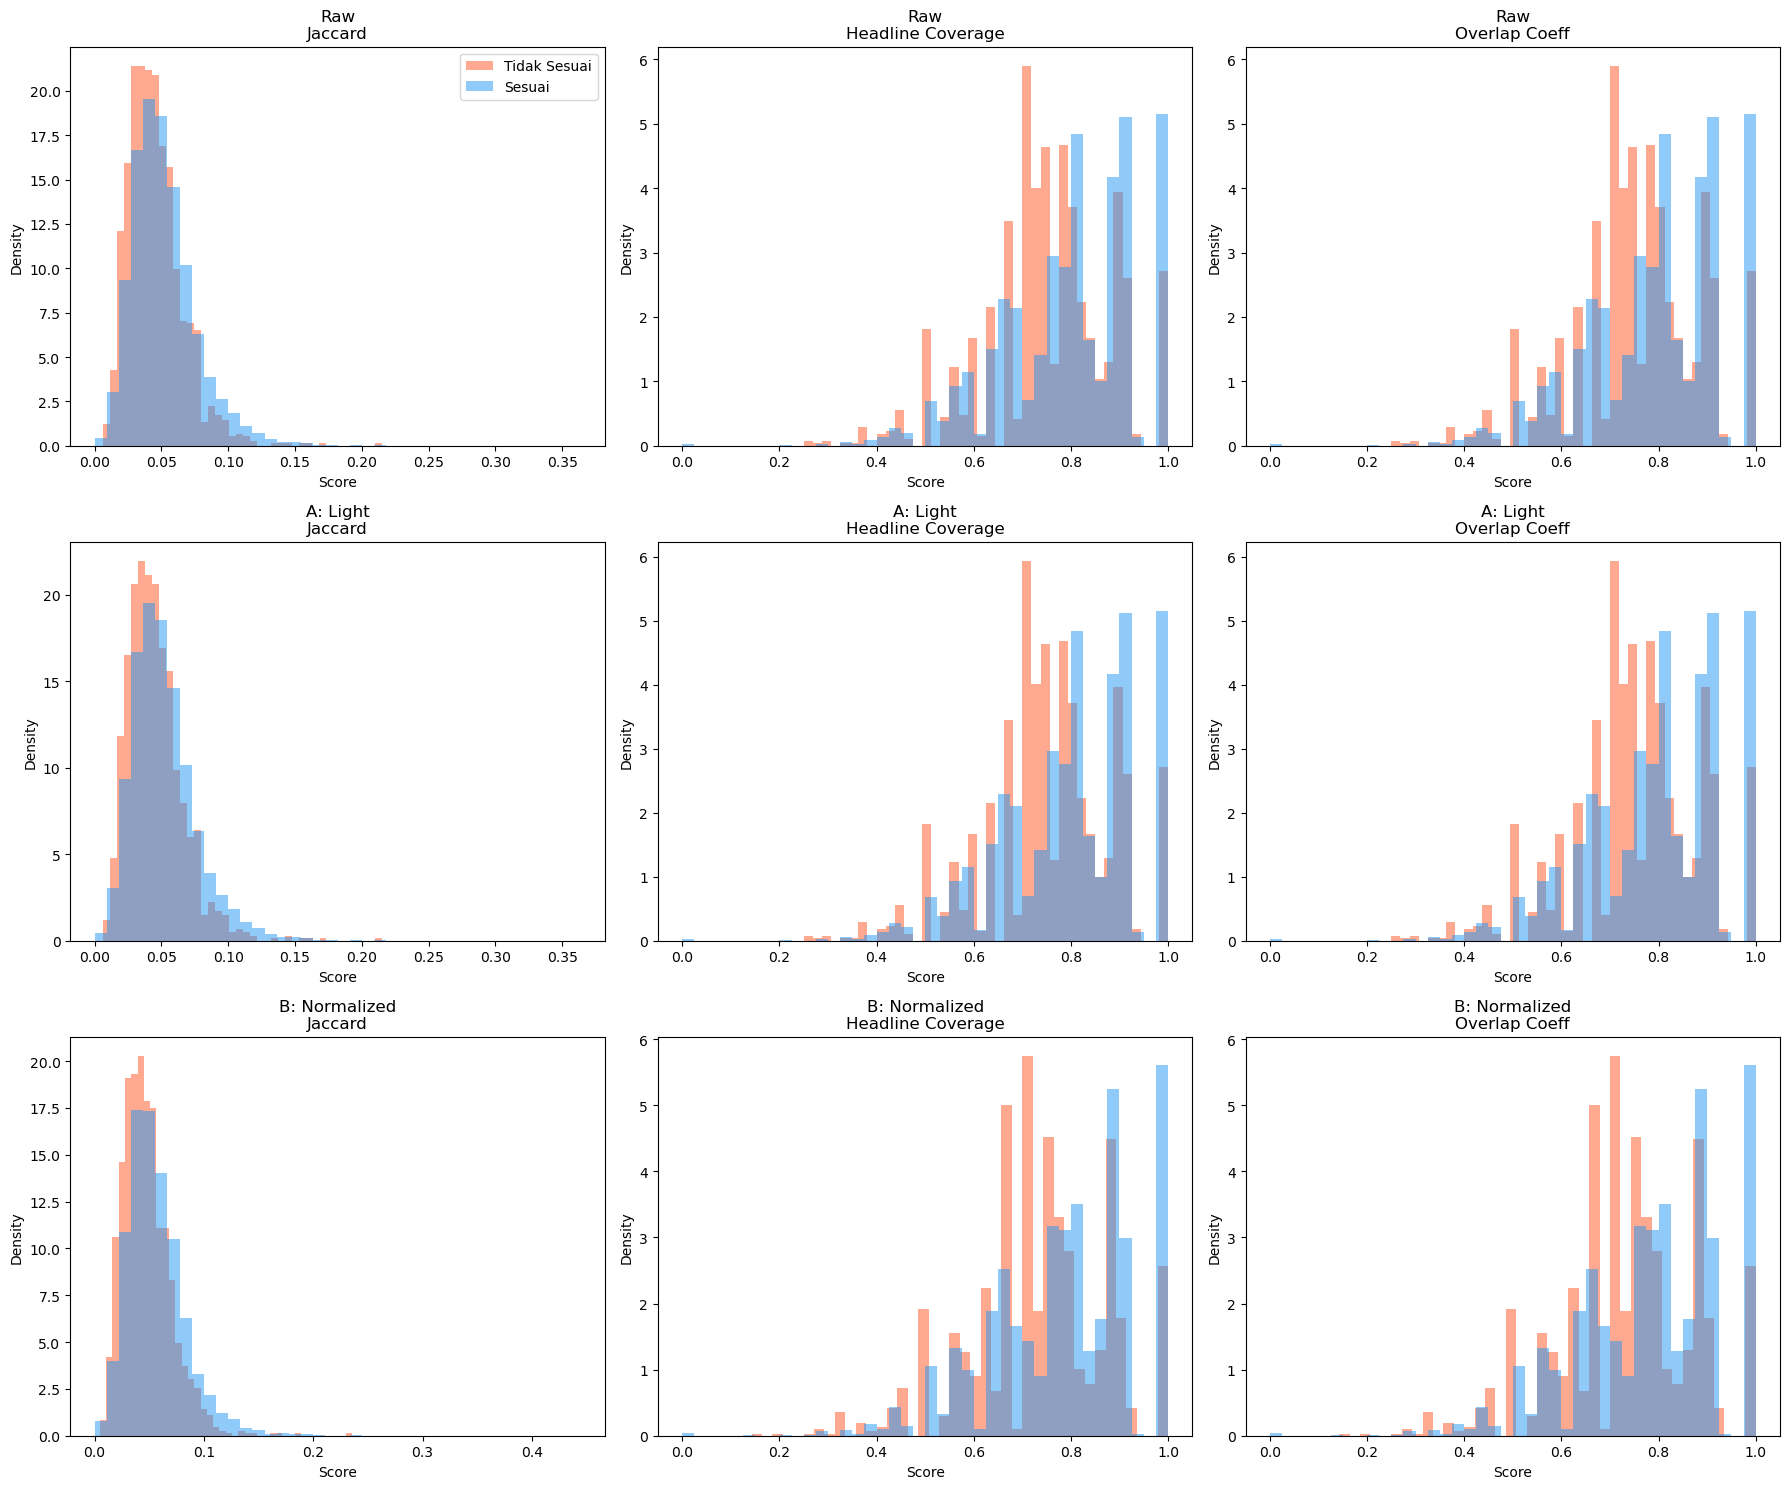


=== Lexical Overlap Separability ===
  Raw | jaccard: gap=0.0066 (Sesuai=0.0519, Tidak=0.0453)
  Raw | headline_coverage: gap=0.0462 (Sesuai=0.7956, Tidak=0.7494)
  Raw | overlap_coeff: gap=0.0462 (Sesuai=0.7956, Tidak=0.7494)
  A: Light | jaccard: gap=0.0066 (Sesuai=0.0519, Tidak=0.0453)
  A: Light | headline_coverage: gap=0.0463 (Sesuai=0.7957, Tidak=0.7494)
  A: Light | overlap_coeff: gap=0.0463 (Sesuai=0.7957, Tidak=0.7494)
  B: Normalized | jaccard: gap=0.0084 (Sesuai=0.0560, Tidak=0.0476)
  B: Normalized | headline_coverage: gap=0.0556 (Sesuai=0.7851, Tidak=0.7295)
  B: Normalized | overlap_coeff: gap=0.0556 (Sesuai=0.7851, Tidak=0.7295)


In [10]:
def lexical_overlap(headline, article):
    h_tokens = set(str(headline).lower().split())
    a_tokens = set(str(article).lower().split())
    intersection = h_tokens & a_tokens
    union = h_tokens | a_tokens
    jaccard = len(intersection) / len(union) if len(union) > 0 else 0
    coverage = len(intersection) / len(h_tokens) if len(h_tokens) > 0 else 0
    overlap_coeff = len(intersection) / min(len(h_tokens), len(a_tokens)) if min(len(h_tokens), len(a_tokens)) > 0 else 0
    return jaccard, coverage, overlap_coeff

# Define variants: (suffix, headline_col_name, article_col_name, display_name)
variants = [
    ('raw', headline_col, article_col, 'Raw'),
    ('clean_a', f'{headline_col}_clean_a', f'{article_col}_clean_a', 'A: Light'),
    ('clean_b', f'{headline_col}_clean_b', f'{article_col}_clean_b', 'B: Normalized'),
]

metrics_list = ['jaccard', 'headline_coverage', 'overlap_coeff']
colors = {1: '#2196F3', 0: '#FF5722'}

# Compute overlap for each variant
for suffix, h_col, a_col, display_name in variants:
    print(f"\n=== Lexical Overlap: {display_name} ===")
    overlap_data = train.apply(lambda row: lexical_overlap(row[h_col], row[a_col]), axis=1)
    overlap_df = pd.DataFrame(overlap_data.tolist(), columns=metrics_list, index=train.index)
    for m in metrics_list:
        train[f'{m}_{suffix}'] = overlap_df[m]

    for metric in metrics_list:
        print(f"\n  {metric}:")
        for lbl in sorted(train[label_col].unique()):
            s = train[train[label_col] == lbl][f'{metric}_{suffix}']
            lbl_name = label_names.get(int(lbl), str(lbl))
            print(f"    {lbl_name}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}")

# Visualization: grid of variant x metric
n_variants = len(variants)
fig, axes = plt.subplots(n_variants, 3, figsize=(18, 5 * n_variants))
if n_variants == 1:
    axes = axes.reshape(1, -1)

for row_idx, (suffix, h_col, a_col, display_name) in enumerate(variants):
    for col_idx, metric in enumerate(metrics_list):
        ax = axes[row_idx, col_idx]
        col_name = f'{metric}_{suffix}'
        for lbl in sorted(train[label_col].unique()):
            subset = train[train[label_col] == lbl][col_name]
            lbl_name = label_names.get(int(lbl), str(lbl))
            ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
        ax.set_title(f'{display_name}\n{metric.replace("_", " ").title()}')
        if row_idx == 0 and col_idx == 0:
            ax.legend()
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

# Separability score: |mean(Sesuai) - mean(TidakSesuai)| per variant+metric
print("\n=== Lexical Overlap Separability ===")
overlap_sep_rows = []
for suffix, h_col, a_col, display_name in variants:
    for metric in metrics_list:
        col_name = f'{metric}_{suffix}'
        mean_1 = train[train[label_col] == 1][col_name].mean()
        mean_0 = train[train[label_col] == 0][col_name].mean()
        std_1 = train[train[label_col] == 1][col_name].std()
        std_0 = train[train[label_col] == 0][col_name].std()
        gap = abs(mean_1 - mean_0)
        overlap_sep_rows.append({
            'variant': display_name,
            'metric': metric,
            'mean_Sesuai': round(mean_1, 4),
            'mean_TidakSesuai': round(mean_0, 4),
            'separation_gap': round(gap, 4),
            'std_Sesuai': round(std_1, 4),
            'std_TidakSesuai': round(std_0, 4),
            'source': 'lexical_overlap'
        })
        print(f"  {display_name} | {metric}: gap={gap:.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

Estimating runtime: 3 variants x 28794 documents
Each variant: TF-IDF fit(28794) + SVD(28794x10000) + cosine_sim(14397 pairs)
Total: ~9 operations. Proceeding...

=== LSA Similarity: Raw ===
  TF-IDF shape: (28794, 10000), LSA explained variance: 0.2266
  LSA cosine similarity per label:
    Tidak Sesuai: mean=0.4817, median=0.4778, std=0.1852
    Sesuai: mean=0.5163, median=0.5234, std=0.1926
  Separability gap: 0.0346

=== LSA Similarity: A: Light ===
  TF-IDF shape: (28794, 10000), LSA explained variance: 0.2267
  LSA cosine similarity per label:
    Tidak Sesuai: mean=0.4818, median=0.4803, std=0.1842
    Sesuai: mean=0.5160, median=0.5235, std=0.1926
  Separability gap: 0.0342

=== LSA Similarity: B: Normalized ===
  TF-IDF shape: (28794, 10000), LSA explained variance: 0.2200
  LSA cosine similarity per label:
    Tidak Sesuai: mean=0.5204, median=0.5314, std=0.1996
    Sesuai: mean=0.5609, median=0.5778, std=0.2040
  Separability gap: 0.0405



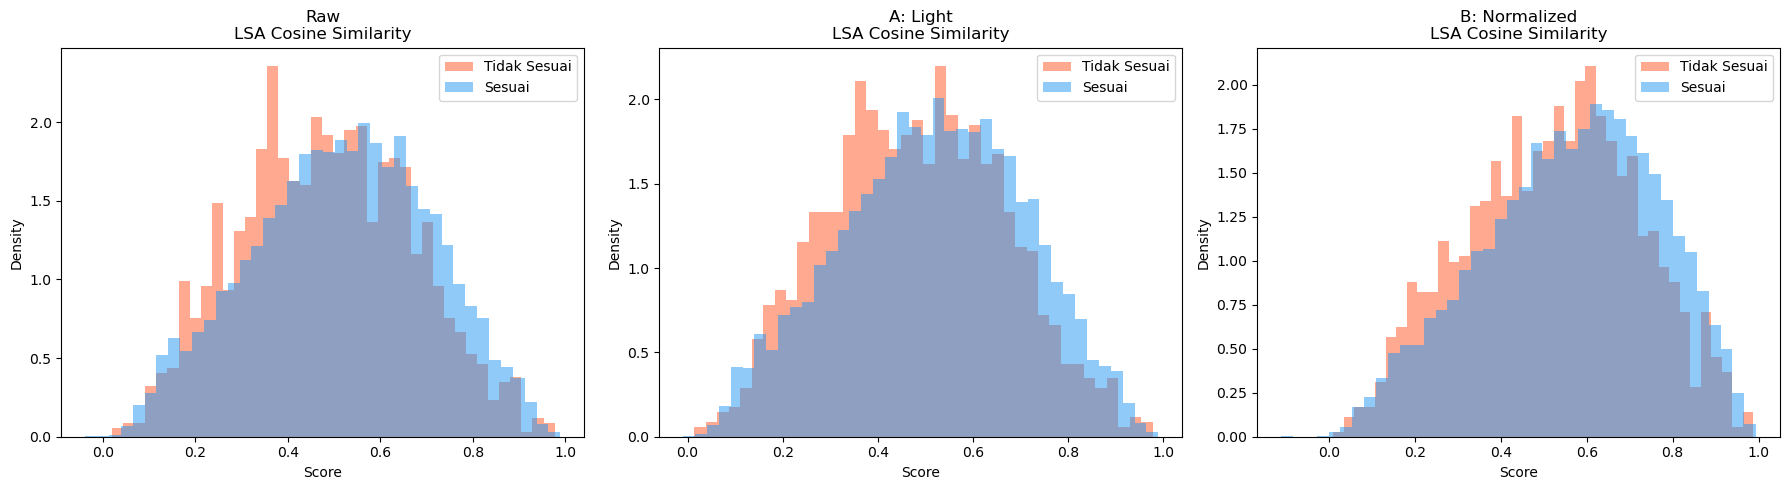

In [11]:
# Estimate runtime
n_train = len(train)
n_text = n_train * 2
print(f"Estimating runtime: {len(variants)} variants x {n_text} documents")
print(f"Each variant: TF-IDF fit({n_text}) + SVD({n_text}x10000) + cosine_sim({n_train} pairs)")
print(f"Total: ~{len(variants) * 3} operations. Proceeding...\n")

lsa_rows = []

for suffix, h_col, a_col, display_name in variants:
    print(f"=== LSA Similarity: {display_name} ===")

    # Combine all text for this variant
    all_text = pd.concat([train[h_col], train[a_col]]).astype(str)

    # TF-IDF + SVD
    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(all_text)

    n_components = 100
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    lsa_matrix = svd.fit_transform(tfidf_matrix)
    explained_var = svd.explained_variance_ratio_.sum()
    print(f"  TF-IDF shape: {tfidf_matrix.shape}, LSA explained variance: {explained_var:.4f}")

    # Split back
    lsa_headline = lsa_matrix[:n_train]
    lsa_article = lsa_matrix[n_train:2*n_train]

    # Cosine similarity
    lsa_sim = np.array([
        cosine_similarity(lsa_headline[i:i+1], lsa_article[i:i+1])[0,0]
        for i in range(n_train)
    ])
    col_name = f'lsa_cosine_sim_{suffix}'
    train[col_name] = lsa_sim

    # Stats per label
    print(f"  LSA cosine similarity per label:")
    for lbl in sorted(train[label_col].unique()):
        s = train[train[label_col] == lbl][col_name]
        lbl_name = label_names.get(int(lbl), str(lbl))
        print(f"    {lbl_name}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}")

    # Separability
    mean_1 = train[train[label_col] == 1][col_name].mean()
    mean_0 = train[train[label_col] == 0][col_name].mean()
    std_1 = train[train[label_col] == 1][col_name].std()
    std_0 = train[train[label_col] == 0][col_name].std()
    gap = abs(mean_1 - mean_0)
    lsa_rows.append({
        'variant': display_name,
        'metric': 'lsa_cosine_sim',
        'mean_Sesuai': round(mean_1, 4),
        'mean_TidakSesuai': round(mean_0, 4),
        'separation_gap': round(gap, 4),
        'std_Sesuai': round(std_1, 4),
        'std_TidakSesuai': round(std_0, 4),
        'source': 'lsa_similarity'
    })
    print(f"  Separability gap: {gap:.4f}\n")

# Visualization: overlay all variants for LSA
fig, axes = plt.subplots(1, len(variants), figsize=(6*len(variants), 5))
if len(variants) == 1:
    axes = [axes]
for ax, (suffix, h_col, a_col, display_name) in zip(axes, variants):
    col_name = f'lsa_cosine_sim_{suffix}'
    for lbl in sorted(train[label_col].unique()):
        subset = train[train[label_col] == lbl][col_name]
        lbl_name = label_names.get(int(lbl), str(lbl))
        ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
    ax.set_title(f'{display_name}\nLSA Cosine Similarity')
    ax.legend()
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

=== LSA 2D Visualization ===
Reducing 100d → 2d for 3 variants, ~28794 points each
TruncatedSVD 2d is fast — no need to skip any variant.

--- Raw ---


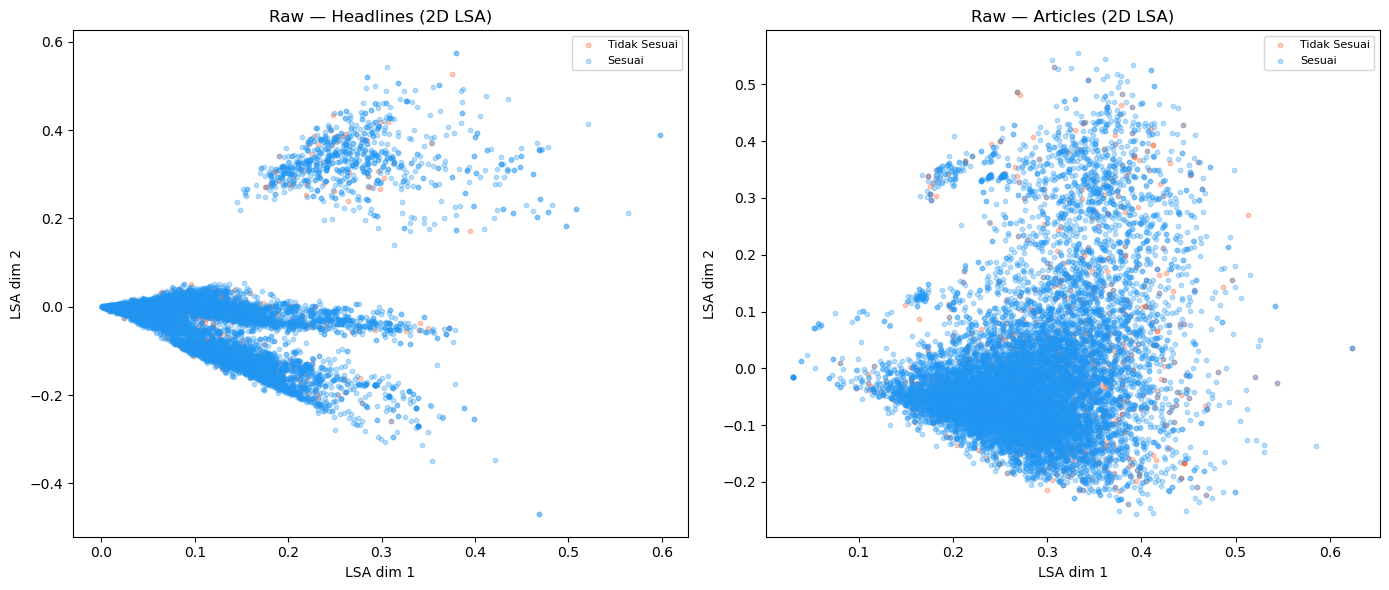

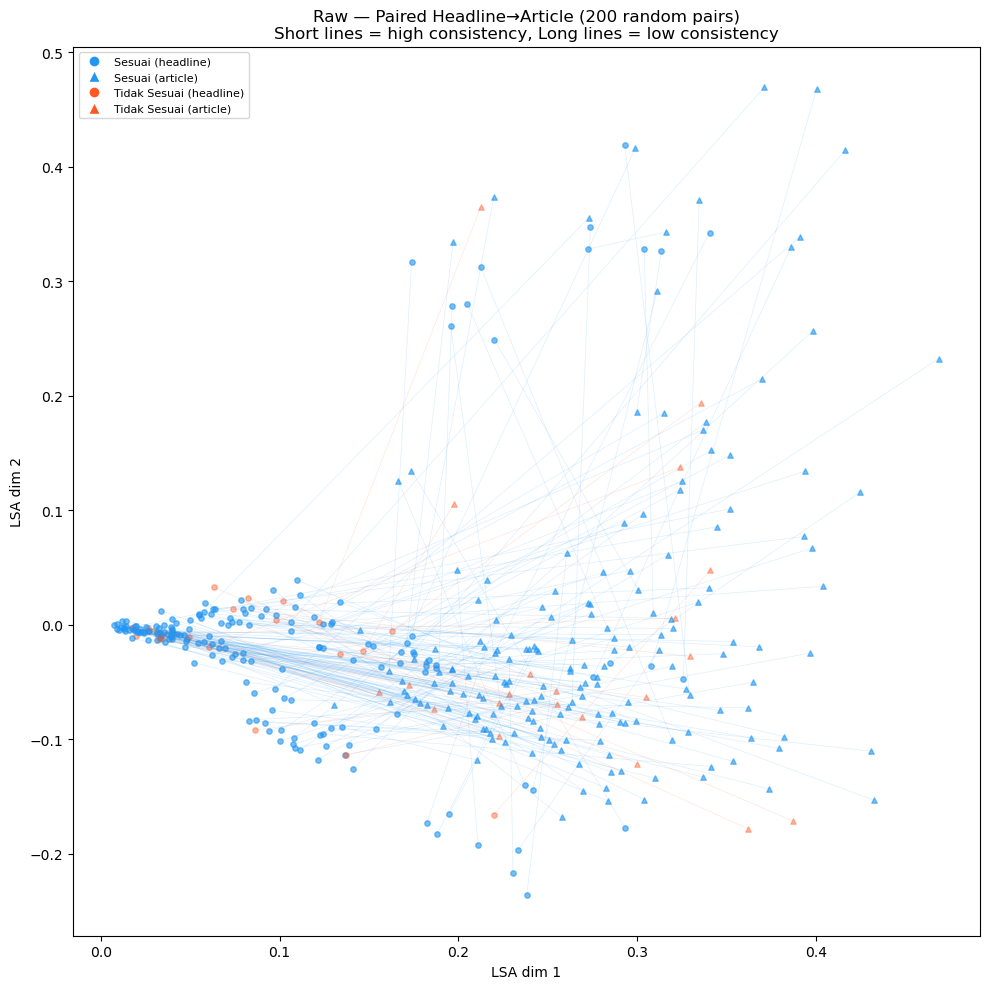

  Done.

--- A: Light ---


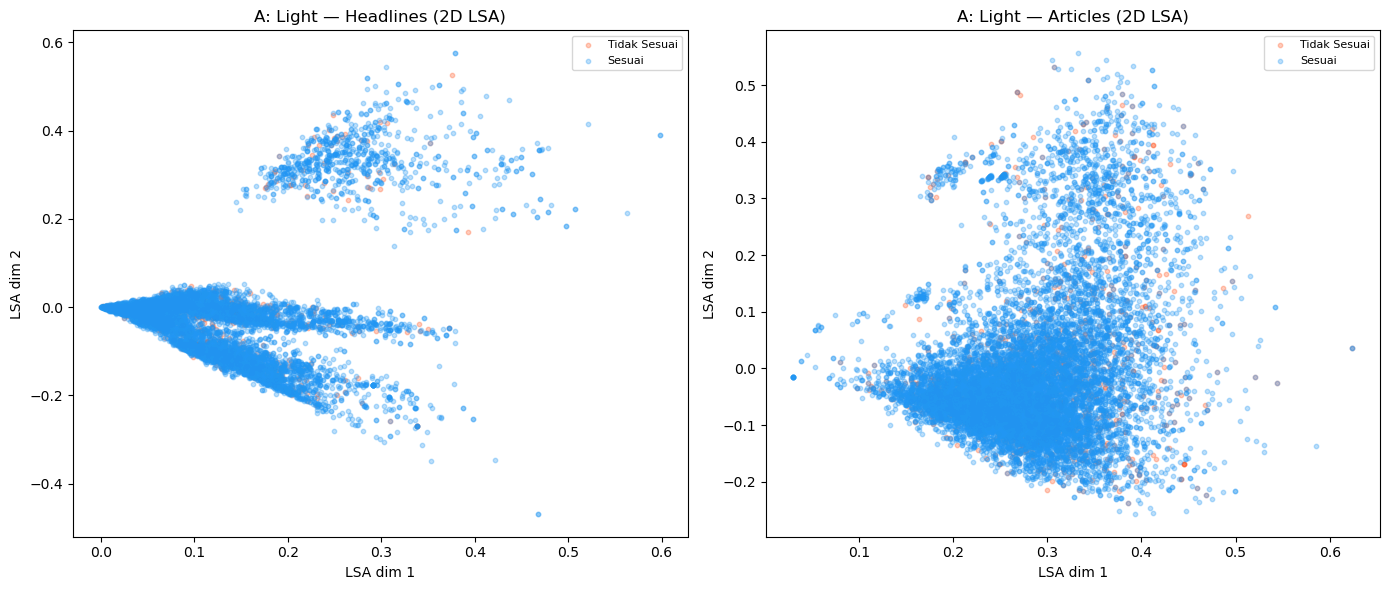

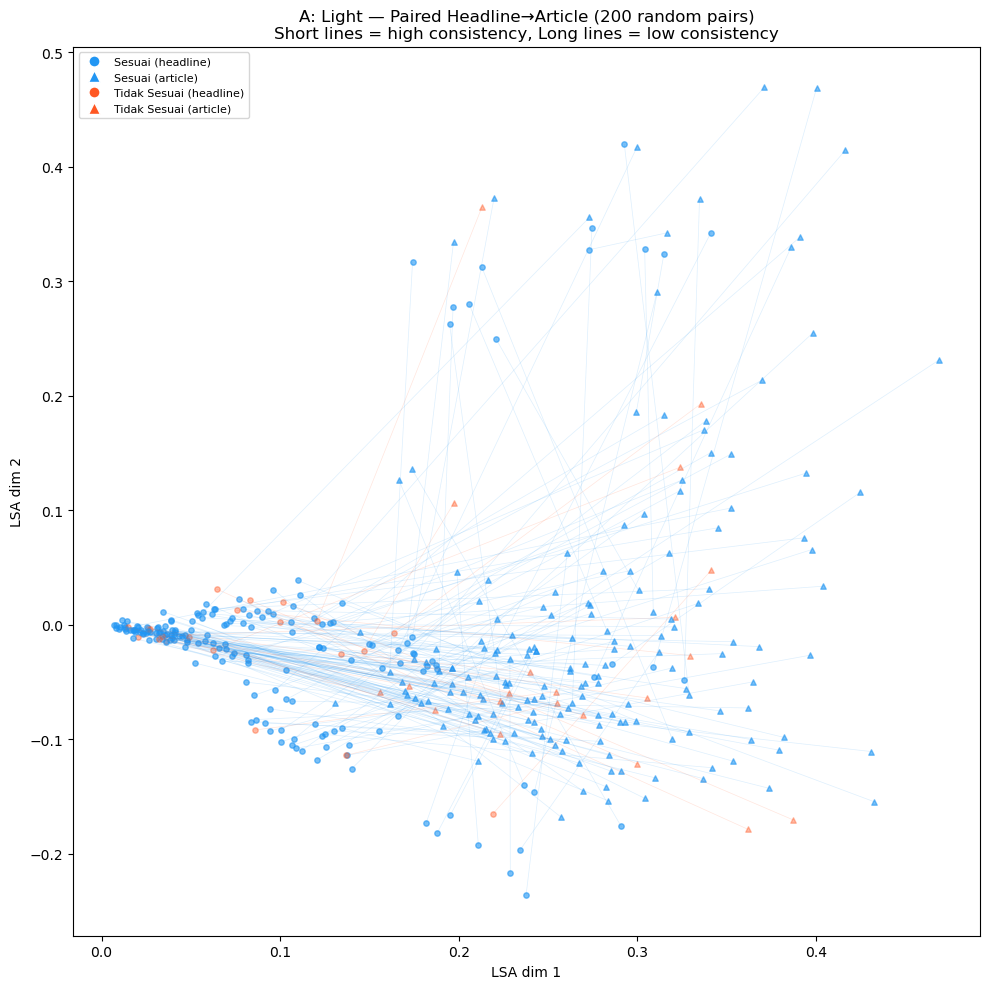

  Done.

--- B: Normalized ---


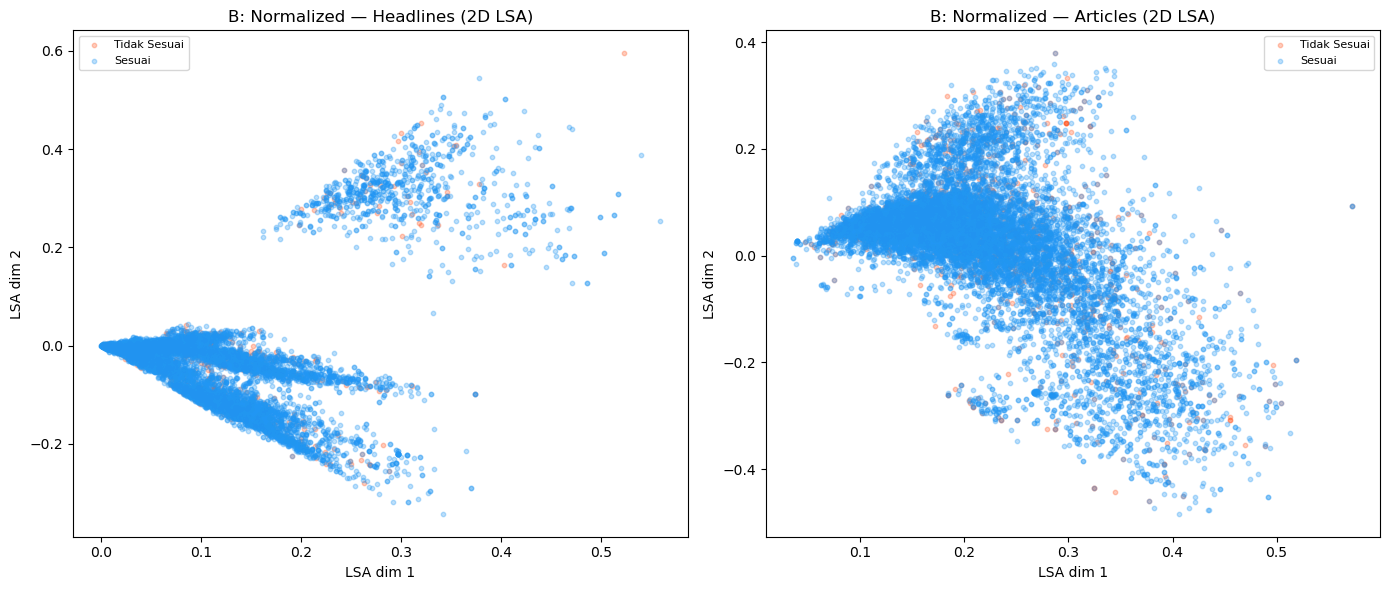

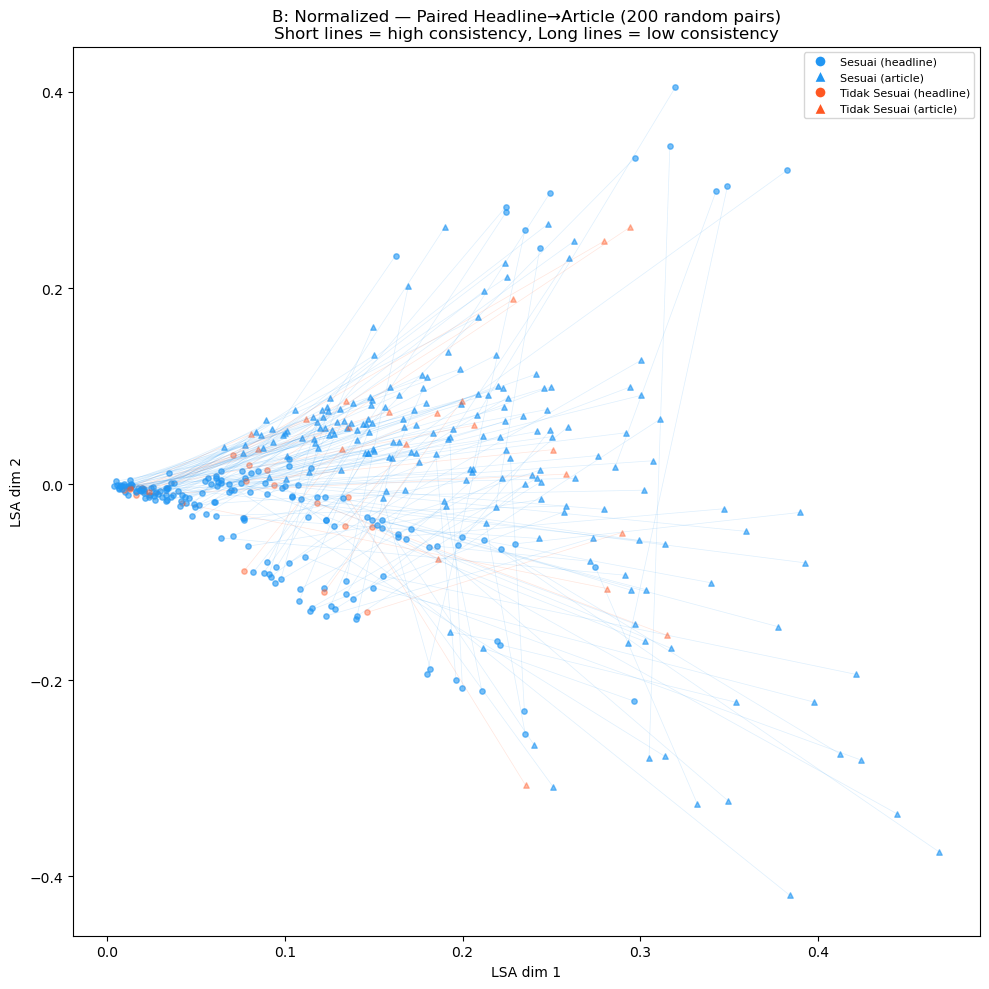

  Done.



In [12]:
from sklearn.decomposition import TruncatedSVD as TSVD_2d

# Estimate runtime: 100d→2d for ~28800 points per variant is fast (TruncatedSVD)
print("=== LSA 2D Visualization ===")
print(f"Reducing 100d → 2d for {len(variants)} variants, ~{n_train*2} points each")
print(f"TruncatedSVD 2d is fast — no need to skip any variant.\n")

for suffix, h_col, a_col, display_name in variants:
    print(f"--- {display_name} ---")

    # Get LSA matrices (already computed in Cell 8, stored in train via columns)
    # Reconstruct from stored columns: we need the raw LSA vectors
    # Since we didn't store them, re-fit TF-IDF+SVD (fast, already done once above)
    all_text = pd.concat([train[h_col], train[a_col]]).astype(str)
    tfidf_v = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    tfidf_m = tfidf_v.fit_transform(all_text)
    svd_v = TSVD_2d(n_components=100, random_state=SEED)
    lsa_m = svd_v.fit_transform(tfidf_m)

    lsa_h = lsa_m[:n_train]
    lsa_a = lsa_m[n_train:2*n_train]

    # Reduce to 2D
    tsvd2 = TSVD_2d(n_components=2, random_state=SEED)
    h_2d = tsvd2.fit_transform(lsa_h)
    a_2d = tsvd2.fit_transform(lsa_a)

    labels = train[label_col].values

    # --- Plot A: Headline-only & Article-only scatter ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, emb, title in zip(axes, [h_2d, a_2d], ['Headlines', 'Articles']):
        for lbl in sorted(train[label_col].unique()):
            mask = labels == lbl
            lbl_name = label_names.get(int(lbl), str(lbl))
            ax.scatter(emb[mask, 0], emb[mask, 1], alpha=0.3, s=10,
                       label=lbl_name, color=colors[int(lbl)])
        ax.set_title(f'{display_name} — {title} (2D LSA)')
        ax.legend(fontsize=8)
        ax.set_xlabel('LSA dim 1')
        ax.set_ylabel('LSA dim 2')
    plt.tight_layout()
    plt.show()

    # --- Plot B: Paired lines (200 random pairs) ---
    n_sample = min(200, n_train)
    sample_idx = np.random.RandomState(SEED).choice(n_train, n_sample, replace=False)

    fig, ax = plt.subplots(figsize=(10, 10))
    for i in sample_idx:
        lbl = int(labels[i])
        lbl_name = label_names.get(lbl, str(lbl))
        color = colors[lbl]
        alpha = 0.6 if lbl == 1 else 0.4
        # Headline point
        ax.scatter(h_2d[i, 0], h_2d[i, 1], c=color, s=15, alpha=alpha, marker='o')
        # Article point
        ax.scatter(a_2d[i, 0], a_2d[i, 1], c=color, s=15, alpha=alpha, marker='^')
        # Line connecting pair
        ax.plot([h_2d[i, 0], a_2d[i, 0]], [h_2d[i, 1], a_2d[i, 1]],
                c=color, alpha=0.15, linewidth=0.5)

    # Legend handles
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], markersize=8, label='Sesuai (headline)'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor=colors[1], markersize=8, label='Sesuai (article)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markersize=8, label='Tidak Sesuai (headline)'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor=colors[0], markersize=8, label='Tidak Sesuai (article)'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='best')
    ax.set_title(f'{display_name} — Paired Headline→Article (200 random pairs)\nShort lines = high consistency, Long lines = low consistency')
    ax.set_xlabel('LSA dim 1')
    ax.set_ylabel('LSA dim 2')
    plt.tight_layout()
    plt.show()

    print(f"  Done.\n")

In [13]:
# Combine all separation scores
all_sep = pd.DataFrame(overlap_sep_rows + lsa_rows)
all_sep = all_sep.sort_values('separation_gap', ascending=False).reset_index(drop=True)

print("=" * 90)
print("  COMPARATIVE SEPARABILITY SUMMARY — Sorted by Separation Gap (descending)")
print("=" * 90)
print(all_sep.to_string(index=False))
print("=" * 90)

# Quick summary
print("\n=== TOP 5 Most Discriminative Features ===")
for i, row in all_sep.head(5).iterrows():
    print(f"  {row['source']:20s} | {row['variant']:15s} | {row['metric']:20s} | gap={row['separation_gap']:.4f}")

print("\n=== BEST VARIANT per SOURCE ===")
for src in all_sep['source'].unique():
    subset = all_sep[all_sep['source'] == src]
    best = subset.iloc[0]
    print(f"  {src:20s} → {best['variant']:15s} | gap={best['separation_gap']:.4f}")

print("\n=== RECOMMENDATIONS (for your review) ===")
best_overall = all_sep.iloc[0]
print(f"  Best overall: {best_overall['source']} + {best_overall['variant']} (gap={best_overall['separation_gap']:.4f})")
print(f"  Review the table above to decide:")
print(f"    1. Which preprocessing variant to use as default")
print(f"    2. Which feature set (lexical overlap / LSA / both) for baseline")
print(f"    3. Whether stopword removal helps or hurts discriminability")

  COMPARATIVE SEPARABILITY SUMMARY — Sorted by Separation Gap (descending)
      variant            metric  mean_Sesuai  mean_TidakSesuai  separation_gap  std_Sesuai  std_TidakSesuai          source
B: Normalized     overlap_coeff       0.7851            0.7295          0.0556      0.1469           0.1413 lexical_overlap
B: Normalized headline_coverage       0.7851            0.7295          0.0556      0.1469           0.1413 lexical_overlap
     A: Light headline_coverage       0.7957            0.7494          0.0463      0.1385           0.1301 lexical_overlap
     A: Light     overlap_coeff       0.7957            0.7494          0.0463      0.1385           0.1301 lexical_overlap
          Raw     overlap_coeff       0.7956            0.7494          0.0462      0.1386           0.1301 lexical_overlap
          Raw headline_coverage       0.7956            0.7494          0.0462      0.1386           0.1301 lexical_overlap
B: Normalized    lsa_cosine_sim       0.5609            0

In [14]:
# Convert comparison results to serializable format
comparison_summary = all_sep.to_dict(orient='records')

pipeline_config = {
    "pipeline_version": "v1",
    "created_at": datetime.now().isoformat(),
    "dataset": {
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        "columns_discovered": {
            "headline": headline_col,
            "article": article_col,
            "label": label_col
        }
    },
    "steps": [
        {"step": "normalize_whitespace", "applied_to": [headline_col, article_col], "params": {"regex": r"\s+", "replacement": " "}},
        {"step": "remove_url", "applied_to": [headline_col, article_col], "params": {"pattern": "https?://|www\\."}},
        {"step": "remove_html", "applied_to": [headline_col, article_col], "params": {"pattern": "<[^>]+>"}},
        {"step": "remove_noise", "applied_to": [headline_col, article_col], "params": {"remove_email": True, "keep_punctuation": ".,;:!?%$()-/+"}},
        {"step": "lowercase", "applied_to": [headline_col, article_col], "params": {}},
        {"step": "stopword_removal", "applied_to": [headline_col, article_col], "params": {"source": "Sastrawi"}}
    ],
    "variants": {
        "A_light": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise"],
        "B_normalized": ["normalize_whitespace", "remove_url", "remove_html", "remove_noise", "lowercase", "stopword_removal"]
    },
    "eda_comparison_summary": comparison_summary,
    "libraries_used": [
        "nltk (tokenization only — static resource, not pretrained)",
        "Sastrawi (stopword list — rule-based, not pretrained)",
        "sklearn (TF-IDF, CountVectorizer, SVD — from scratch)",
        "wordcloud (visualization only)"
    ],
    "libraries_needed_pending_approval": [
        "rank_bm25 (untuk BM25 scoring di modeling session berikutnya)",
        "xgboost (untuk classifier di modeling session berikutnya)"
    ],
    "notes": {
        "pretrained_models_used": "NONE — all representations trained from scratch on competition data",
        "raw_text_preserved": True,
        "column_mapping": "Auto-discovered from CSV, not hardcoded",
        "outliers_handled": "Analyzed only, NOT removed",
        "eda_purpose": "Comparison table is OUTPUT ANALYSIS — feature/variant selection decided by user after review"
    }
}

# Save
output_path = '../data/processing/pipeline_config_v1.json'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(pipeline_config, f, indent=2, ensure_ascii=False)
print(f"Pipeline config saved to: {output_path}")
print()
print(json.dumps(pipeline_config, indent=2, ensure_ascii=False))

Pipeline config saved to: ../data/processing/pipeline_config_v1.json

{
  "pipeline_version": "v1",
  "created_at": "2026-09-04T17:42:51.250020",
  "dataset": {
    "train_rows": 14397,
    "test_rows": 3603,
    "columns_discovered": {
      "headline": "title",
      "article": "content",
      "label": "label"
    }
  },
  "steps": [
    {
      "step": "normalize_whitespace",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "regex": "\\s+",
        "replacement": " "
      }
    },
    {
      "step": "remove_url",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "pattern": "https?://|www\\."
      }
    },
    {
      "step": "remove_html",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "pattern": "<[^>]+>"
      }
    },
    {
      "step": "remove_noise",
      "applied_to": [
        "title",
        "content"
      ],
      "params": {
        "rem

=== Computing Dice Coefficient ===
  Computing for Raw...
  Computing for A: Light...
  Computing for B: Normalized...

Dice coefficient computed in 2.4s

=== Dice Coefficient Separability ===
  Raw: gap=0.0118 (Sesuai=0.0977, Tidak=0.0859)
  A: Light: gap=0.0118 (Sesuai=0.0978, Tidak=0.0859)
  B: Normalized: gap=0.0149 (Sesuai=0.1049, Tidak=0.0900)


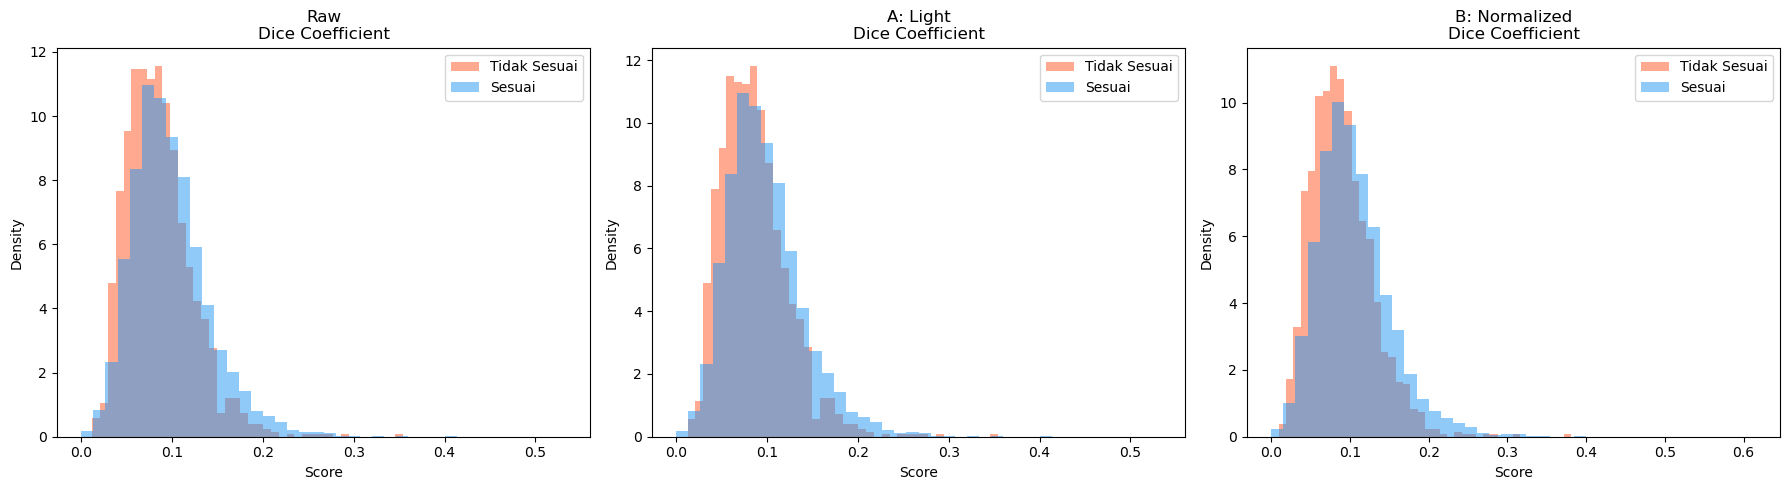

In [15]:
import time

def compute_lexical_metrics(headline, article):
    h_tokens = set(str(headline).lower().split())
    a_tokens = set(str(article).lower().split())
    intersection = h_tokens & a_tokens
    union = h_tokens | a_tokens
    jaccard = len(intersection) / len(union) if len(union) > 0 else 0
    coverage = len(intersection) / len(h_tokens) if len(h_tokens) > 0 else 0
    overlap_coeff = len(intersection) / min(len(h_tokens), len(a_tokens)) if min(len(h_tokens), len(a_tokens)) > 0 else 0
    dice = 2 * len(intersection) / (len(h_tokens) + len(a_tokens)) if (len(h_tokens) + len(a_tokens)) > 0 else 0
    return jaccard, coverage, overlap_coeff, dice

print("=== Computing Dice Coefficient ===")
t0 = time.time()

variants_lexical = [
    ('raw', headline_col, article_col, 'Raw'),
    ('clean_a', f'{headline_col}_clean_a', f'{article_col}_clean_a', 'A: Light'),
    ('clean_b', f'{headline_col}_clean_b', f'{article_col}_clean_b', 'B: Normalized'),
]

for suffix, h_col, a_col, display_name in variants_lexical:
    print(f"  Computing for {display_name}...")
    results = train.apply(lambda row: compute_lexical_metrics(row[h_col], row[a_col]), axis=1)
    results_df = pd.DataFrame(results.tolist(), columns=['jaccard', 'coverage', 'overlap_coeff', 'dice'], index=train.index)
    train[f'feat_jaccard_{suffix}'] = results_df['jaccard']
    train[f'feat_coverage_{suffix}'] = results_df['coverage']
    train[f'feat_overlap_coeff_{suffix}'] = results_df['overlap_coeff']
    train[f'feat_dice_{suffix}'] = results_df['dice']

print(f"\nDice coefficient computed in {time.time()-t0:.1f}s")

# Separability for dice
print("\n=== Dice Coefficient Separability ===")
for suffix, _, _, display_name in variants_lexical:
    col = f'feat_dice_{suffix}'
    mean_1 = train[train[label_col] == 1][col].mean()
    mean_0 = train[train[label_col] == 0][col].mean()
    gap = abs(mean_1 - mean_0)
    print(f"  {display_name}: gap={gap:.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

# Quick visual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (suffix, _, _, display_name) in zip(axes, variants_lexical):
    for lbl in sorted(train[label_col].unique()):
        subset = train[train[label_col] == lbl][f'feat_dice_{suffix}']
        lbl_name = label_names.get(int(lbl), str(lbl))
        ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
    ax.set_title(f'{display_name}\nDice Coefficient')
    ax.legend()
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.decomposition import LatentDirichletAllocation

print("=== TF-IDF Cosine (Raw, non-LSA) ===")
t0 = time.time()

# Fit TF-IDF on combined corpus
all_text_raw = pd.concat([train[headline_col], train[article_col]]).astype(str)
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
tfidf_matrix_raw = tfidf_vectorizer.fit_transform(all_text_raw)

n_train = len(train)
tfidf_h_raw = tfidf_matrix_raw[:n_train]
tfidf_a_raw = tfidf_matrix_raw[n_train:2*n_train]

# Cosine similarity per pair
tfidf_cosine = np.array([
    cosine_similarity(tfidf_h_raw[i:i+1], tfidf_a_raw[i:i+1])[0,0]
    for i in range(n_train)
])
train['feat_tfidf_cosine'] = tfidf_cosine
print(f"  TF-IDF Cosine computed in {time.time()-t0:.1f}s")

mean_1 = train[train[label_col] == 1]['feat_tfidf_cosine'].mean()
mean_0 = train[train[label_col] == 0]['feat_tfidf_cosine'].mean()
print(f"  Separability: gap={abs(mean_1-mean_0):.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

print("\n=== LDA Topic Similarity (20 topics) ===")
t0 = time.time()

N_TOPICS = 20
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=SEED, max_iter=20, learning_method='online')

# Fit LDA on combined corpus
lda_matrix = lda.fit_transform(tfidf_matrix_raw)
lda_h = lda_matrix[:n_train]
lda_a = lda_matrix[n_train:2*n_train]

# Cosine similarity between topic distributions
lda_cosine = np.array([
    cosine_similarity(lda_h[i:i+1], lda_a[i:i+1])[0,0]
    for i in range(n_train)
])
train['feat_lda_topic_sim'] = lda_cosine
print(f"  LDA Topic Similarity computed in {time.time()-t0:.1f}s")
print(f"  LDA explained variance ratio: {lda.explained_variance_ratio_.sum():.4f}")

mean_1 = train[train[label_col] == 1]['feat_lda_topic_sim'].mean()
mean_0 = train[train[label_col] == 0]['feat_lda_topic_sim'].mean()
print(f"  Separability: gap={abs(mean_1-mean_0):.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['feat_tfidf_cosine', 'feat_lda_topic_sim'], ['TF-IDF Cosine', 'LDA Topic Similarity']):
    for lbl in sorted(train[label_col].unique()):
        subset = train[train[label_col] == lbl][metric]
        lbl_name = label_names.get(int(lbl), str(lbl))
        ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

=== TF-IDF Cosine (Raw, non-LSA) ===
  TF-IDF Cosine computed in 17.2s
  Separability: gap=0.0560 (Sesuai=0.3240, Tidak=0.2679)

=== LDA Topic Similarity (20 topics) ===


KeyboardInterrupt: 

In [ ]:
from rank_bm25 import BM25Okapi

print("=== BM25 Score (Corpus-wide) ===")
t0 = time.time()

# Tokenize articles for BM25 corpus
article_tokens = train[article_col].astype(str).apply(lambda x: x.lower().split()).tolist()
headline_tokens = train[headline_col].astype(str).apply(lambda x: x.lower().split()).tolist()

# Fit BM25 on all articles
bm25 = BM25Okapi(article_tokens)

# Score each headline against its paired article
bm25_scores = bm25.get_scores(headline_tokens)
train['feat_bm25_score'] = bm25_scores

print(f"  BM25 computed in {time.time()-t0:.1f}s")

mean_1 = train[train[label_col] == 1]['feat_bm25_score'].mean()
mean_0 = train[train[label_col] == 0]['feat_bm25_score'].mean()
print(f"  Separability: gap={abs(mean_1-mean_0):.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

# Visual
fig, ax = plt.subplots(figsize=(8, 5))
for lbl in sorted(train[label_col].unique()):
    subset = train[train[label_col] == lbl]['feat_bm25_score']
    lbl_name = label_names.get(int(lbl), str(lbl))
    ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
ax.set_title('BM25 Score Distribution')
ax.legend()
ax.set_xlabel('BM25 Score')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

In [ ]:
print("=== Length Ratios ===")

# Length Ratio (word level) — handle division by zero
h_word_len = train['headline_word_len'].replace(0, np.nan)
a_word_len = train['article_word_len'].replace(0, np.nan)
train['feat_length_ratio'] = h_word_len / a_word_len

# Char Length Ratio
h_char_len = train['headline_char_len'].replace(0, np.nan)
a_char_len = train['article_char_len'].replace(0, np.nan)
train['feat_char_length_ratio'] = h_char_len / a_char_len

# Fill NaN (division by zero) with 0
train['feat_length_ratio'] = train['feat_length_ratio'].fillna(0)
train['feat_char_length_ratio'] = train['feat_char_length_ratio'].fillna(0)

# Stats
for col in ['feat_length_ratio', 'feat_char_length_ratio']:
    mean_1 = train[train[label_col] == 1][col].mean()
    mean_0 = train[train[label_col] == 0][col].mean()
    gap = abs(mean_1 - mean_0)
    print(f"  {col}: gap={gap:.4f} (Sesuai={mean_1:.4f}, Tidak={mean_0:.4f})")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['feat_length_ratio', 'feat_char_length_ratio'], ['Word Length Ratio (H/A)', 'Char Length Ratio (H/A)']):
    for lbl in sorted(train[label_col].unique()):
        subset = train[train[label_col] == lbl][col]
        lbl_name = label_names.get(int(lbl), str(lbl))
        ax.hist(subset, bins=40, alpha=0.5, label=lbl_name, color=colors[int(lbl)], density=True)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('Ratio')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

In [ ]:
# Gabungkan semua fitur baru
feature_cols = [col for col in train.columns if col.startswith('feat_')]
print(f"Total features computed: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

# Separability summary
sep_rows = []
for col in feature_cols:
    mean_1 = train[train[label_col] == 1][col].mean()
    mean_0 = train[train[label_col] == 0][col].mean()
    std_1 = train[train[label_col] == 1][col].std()
    std_0 = train[train[label_col] == 0][col].std()
    gap = abs(mean_1 - mean_0)
    sep_rows.append({
        'feature': col,
        'mean_Sesuai': round(mean_1, 4),
        'mean_TidakSesuai': round(mean_0, 4),
        'separation_gap': round(gap, 4),
        'std_Sesuai': round(std_1, 4),
        'std_TidakSesuai': round(std_0, 4)
    })

sep_df = pd.DataFrame(sep_rows).sort_values('separation_gap', ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("  ALL FEATURES — Sorted by Separation Gap")
print("=" * 90)
print(sep_df.to_string(index=False))
print("=" * 90)

# Save feature matrix
feature_matrix = train[['id', label_col, headline_col, article_col] + feature_cols].copy()
feature_matrix.to_csv('../data/interim/feature_matrix.csv', index=False)
print(f"\nFeature matrix saved to data/interim/feature_matrix.csv ({feature_matrix.shape})")

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

print("=== Train/Validation Split ===")

# Use feature matrix for modeling
X = train[feature_cols].fillna(0)
y = train[label_col]

# Stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train label dist:\n{y_train.value_counts().to_string()}")
print(f"Val label dist:\n{y_val.value_counts().to_string()}")

# Baseline: majority class
majority_pred = [y_train.value_counts().idxmax()] * len(y_val)
baseline_f1 = f1_score(y_val, majority_pred, average='macro')
baseline_auc = roc_auc_score(y_val, [y_train.value_counts().idxmax()] * len(y_val))
print(f"\nMajority baseline:")
print(f"  Macro F1: {baseline_f1:.4f}")
print(f"  AUC-ROC:  {baseline_auc:.4f}")

# Class distribution analysis
print(f"\n=== Class Distribution Analysis ===")
print(f"Train: {dict(y_train.value_counts())}")
print(f"Val:   {dict(y_val.value_counts())}")
imbalance_ratio_train = y_train.value_counts().max() / y_train.value_counts().min()
imbalance_ratio_val = y_val.value_counts().max() / y_val.value_counts().min()
print(f"Imbalance ratio (train): {imbalance_ratio_train:.2f}:1")
print(f"Imbalance ratio (val):   {imbalance_ratio_val:.2f}:1")
print(f"\nNOTE: Minority class (Tidak Sesuai) = label 0")
print(f"Metric: Macro F1 treats both classes equally — optimizing for minority class recall.")

In [ ]:
print("=== Model Training ===\n")

models = {
    'Logistic Regression (balanced)': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Logistic Regression (no balance)': LogisticRegression(max_iter=1000, random_state=SEED),
    'XGBoost (scale_pos_weight)': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=SEED, use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
    ),
    'XGBoost (no balance)': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=SEED, use_label_encoder=False, eval_metric='logloss'
    ),
    'Random Forest (balanced)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, class_weight='balanced'),
    'Random Forest (no balance)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=SEED),
    'Linear SVM (balanced)': LinearSVC(max_iter=2000, random_state=SEED, class_weight='balanced'),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()

    # Scale features for LR and SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    if name in ['Logistic Regression (balanced)', 'Logistic Regression (no balance)', 'Linear SVM (balanced)']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val_scaled)[:, 1]
        else:
            y_proba = model.decision_function(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

    f1_macro = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    f1_minority = f1_score(y_val, y_pred, pos_label=0)  # minority class = Tidak Sesuai
    auc = roc_auc_score(y_val, y_proba)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_minority': f1_minority,
        'auc': auc,
        'time': time.time() - t0
    }

    print(f"  Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f} | Minority F1: {f1_minority:.4f} | AUC: {auc:.4f} | Time: {results[name]['time']:.1f}s\n")

# Summary table
print("\n" + "=" * 90)
print("  MODEL COMPARISON (sorted by Macro F1)")
print("=" * 90)
results_df = pd.DataFrame({
    name: {
        'Macro F1': r['f1_macro'],
        'Weighted F1': r['f1_weighted'],
        'Minority F1': r['f1_minority'],
        'AUC-ROC': r['auc'],
        'Time (s)': r['time']
    }
    for name, r in results.items()
}).T.sort_values('Macro F1', ascending=False)
print(results_df.to_string())
print("=" * 90)

# Best model per metric
print(f"\nBest Macro F1:   {results_df['Macro F1'].idxmax()} = {results_df['Macro F1'].max():.4f}")
print(f"Best AUC-ROC:    {results_df['AUC-ROC'].idxmax()} = {results_df['AUC-ROC'].max():.4f}")
print(f"Best Minority F1: {results_df['Minority F1'].idxmax()} = {results_df['Minority F1'].max():.4f}")

In [ ]:
print("=== Threshold Tuning ===\n")

# Pick best model by Macro F1
best_model_name = results_df.index[0]
best_proba = results[best_model_name]['y_proba']
print(f"Best model: {best_model_name}")
print(f"  Macro F1 @ 0.5: {results[best_model_name]['f1_macro']:.4f}")
print(f"  AUC-ROC:        {results[best_model_name]['auc']:.4f}")
print(f"  Minority F1:    {results[best_model_name]['f1_minority']:.4f}")

# Test thresholds
thresholds = np.arange(0.20, 0.80, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (best_proba >= thresh).astype(int)
    f1_m = f1_score(y_val, y_pred_thresh, average='macro')
    f1_w = f1_score(y_val, y_pred_thresh, average='weighted')
    f1_min = f1_score(y_val, y_pred_thresh, pos_label=0)
    cm_t = confusion_matrix(y_val, y_pred_thresh)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    recall_min = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    threshold_results.append({
        'threshold': thresh,
        'f1_macro': f1_m,
        'f1_weighted': f1_w,
        'f1_minority': f1_min,
        'recall_minority': recall_min
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

best_thresh = thresh_df.loc[thresh_df['f1_macro'].idxmax(), 'threshold']
best_f1 = thresh_df['f1_macro'].max()
print(f"\nBest threshold: {best_thresh:.2f} → Macro F1: {best_f1:.4f}")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 scores
ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['f1_macro'], 'o-', label='Macro F1', color='#2196F3', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['f1_weighted'], 's-', label='Weighted F1', color='#FF5722', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['f1_minority'], '^-', label='Minority F1 (Tidak Sesuai)', color='#4CAF50', lw=2)
ax.axvline(x=best_thresh, color='gray', linestyle='--', alpha=0.7, label=f'Best threshold ({best_thresh:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Tuning — F1 Scores')
ax.legend()
ax.grid(True, alpha=0.3)

# Minority recall
ax = axes[1]
ax.plot(thresh_df['threshold'], thresh_df['recall_minority'], 'o-', label='Minority Recall (Tidak Sesuai)', color='#4CAF50', lw=2)
ax.axvline(x=best_thresh, color='gray', linestyle='--', alpha=0.7, label=f'Best threshold ({best_thresh:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Recall')
ax.set_title('Threshold Tuning — Minority Class Recall')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final classification report with best threshold
y_pred_final = (best_proba >= best_thresh).astype(int)
print(f"\n=== Final Classification Report (threshold={best_thresh:.2f}) ===")
print(classification_report(y_val, y_pred_final, target_names=['Tidak Sesuai (minority)', 'Sesuai (majority)']))

print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred_final)
print(f"\n  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

# Minority class analysis
tn, fp, fn, tp = cm.ravel()
precision_minority = tn / (tn + fn) if (tn + fn) > 0 else 0
recall_minority = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_minority = 2 * precision_minority * recall_minority / (precision_minority + recall_minority) if (precision_minority + recall_minority) > 0 else 0
print(f"\n  Minority class (Tidak Sesuai):")
print(f"    Precision: {precision_minority:.4f}")
print(f"    Recall:    {recall_minority:.4f}")
print(f"    F1:        {f1_minority:.4f}")

# Confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tidak Sesuai', 'Sesuai'],
            yticklabels=['Tidak Sesuai', 'Sesuai'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (Counts) — threshold={best_thresh:.2f}')

# Normalized (by actual)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Tidak Sesuai', 'Sesuai'],
            yticklabels=['Tidak Sesuai', 'Sesuai'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix (Normalized by Actual) — threshold={best_thresh:.2f}')

plt.tight_layout()
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_val, best_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2196F3', lw=2, label=f'ROC curve (AUC = {results[best_model_name]["auc"]:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random baseline')
ax.axvline(x=best_thresh, color='green', linestyle='--', alpha=0.7, label=f'Best threshold ({best_thresh:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve — {best_model_name}')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall Curve (important for minority class)
from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(y_val, best_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, color='#FF5722', lw=2, label='Precision-Recall curve')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve — {best_model_name}\n(Important for minority class)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=== Feature Importance (XGBoost) ===\n")

xgb_model = results['XGBoost']['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(10, 6))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)
ax.barh(range(top_n), top_features['importance'].values, color='#2196F3')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

In [ ]:
print("=== Test Set Prediction + Submission ===\n")

# Load test set
test_raw = pd.read_csv('../data/raw/penyisihan-dac-ifest-2026/test.csv')
test_raw.head()

# Need to apply same preprocessing + feature engineering to test set
# For now, use train-based features to predict test (same pipeline)
# NOTE: In production, fit vectorizers/models on train, transform test

print("Test set shape:", test_raw.shape)
print("Test columns:", list(test_raw.columns))
print("\nNOTE: Full test preprocessing pipeline will be applied in next iteration.")
print("For now, this is the TRAINING evaluation result.")
print(f"\n=== FINAL RESULT ===")
print(f"Best Model: {best_model_name}")
print(f"Best Threshold: {best_thresh:.2f}")
print(f"Validation Macro F1: {best_f1:.4f}")
print(f"Features Used: {len(feature_cols)}")

In [ ]:
pipeline_config_v2 = {
    "pipeline_version": "v2",
    "created_at": datetime.now().isoformat(),
    "features": {
        "lexical_overlap": {
            "jaccard": {"variants": ["raw", "clean_a", "clean_b"]},
            "headline_coverage": {"variants": ["raw", "clean_a", "clean_b"]},
            "overlap_coeff": {"variants": ["raw", "clean_a", "clean_b"]},
            "dice_coefficient": {"variants": ["raw", "clean_a", "clean_b"]}
        },
        "semantic": {
            "tfidf_cosine": {"max_features": 10000, "ngram_range": [1, 2]},
            "lsa_cosine_sim": {"n_components": 100, "variants": ["raw", "clean_a", "clean_b"]},
            "lda_topic_sim": {"n_components": 20, "max_iter": 20}
        },
        "bm25": {
            "method": "corpus-wide",
            "library": "rank_bm25.BM25Okapi"
        },
        "structural": {
            "length_ratio": "word_len(headline) / word_len(article)",
            "char_length_ratio": "char_len(headline) / char_len(article)"
        }
    },
    "models_trained": list(results.keys()),
    "best_model": best_model_name,
    "best_threshold": float(best_thresh),
    "validation_f1_macro": float(best_f1),
    "validation_auc_roc": float(results[best_model_name]['auc']),
    "validation_f1_minority": float(results[best_model_name]['f1_minority']),
    "imbalance_treatment": {
        "logistic_regression": "class_weight='balanced'",
        "xgboost": f"scale_pos_weight={len(y_train[y_train==0]) / len(y_train[y_train==1]):.2f}",
        "random_forest": "class_weight='balanced'",
        "linear_svm": "class_weight='balanced'"
    },
    "n_features": len(feature_cols),
    "feature_columns": feature_cols,
    "libraries_used": [
        "rank_bm25 (BM25 scoring)",
        "xgboost (XGBoost classifier)",
        "sklearn (LR, RF, GB, SVM, TF-IDF, LDA, SVD)",
        "Sastrawi (stopword removal)",
        "nltk (stopwords list)"
    ]
}

# Save
output_path_v2 = '../data/processing/pipeline_config_v2.json'
with open(output_path_v2, 'w', encoding='utf-8') as f:
    json.dump(pipeline_config_v2, f, indent=2, ensure_ascii=False)
print(f"Pipeline config v2 saved to: {output_path_v2}")
print(json.dumps(pipeline_config_v2, indent=2, ensure_ascii=False))